In [1]:
import polars as pl 
from pathlib import Path

root_folder = Path("../data/processed")
training_path = root_folder / "train"

# Scanning the dataset
df = pl.scan_parquet(training_path)

In [3]:
df.collect_schema()

Schema([('problem', String), ('solution', String)])

In [ ]:
# collecting number problems 

number_of_problems = df.select(
    pl.col("problem").unique_counts()
)

In [6]:
number_of_problems = number_of_problems.collect()

In [9]:
number_of_problems.shape

(7495, 1)

In [11]:
# Inspecting the number of problems with solutions 
n_problems_w_n_solutions = df.group_by(
    pl.col("problem")
).agg(
    pl.len().alias("counts")
).filter(
    pl.col("counts") > 1
).collect()

In [12]:
n_problems_w_n_solutions

problem,counts
str,u32
"""You are given a weighted tree …",45
"""Innokenty is a president of a …",7
"""You have N apples, called Appl…",192
"""Little Artem has invented a ti…",4
"""Given a string of length n s =…",4
…,…
"""Little Susie loves strings. To…",224
"""When Masha came to math classe…",38
"""Peter decided to wish happy bi…",66


In [14]:
n_problems_w_n_solutions["counts"].describe()

statistic,value
str,f64
"""count""",6874.0
"""null_count""",0.0
"""mean""",214.092086
"""std""",562.821648
"""min""",2.0
"""25%""",14.0
"""50%""",82.0
"""75%""",200.0
"""max""",13856.0


C:\Users\amine\AppData\Local\Temp\ipykernel_28752\268018642.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(counts.to_list(), vert=False)


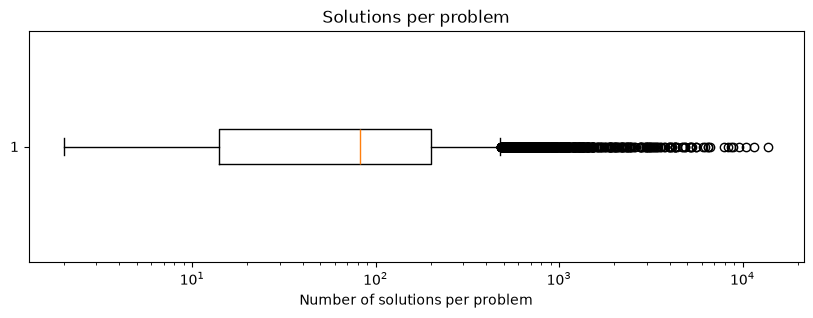

In [22]:
import matplotlib.pyplot as plt

counts = n_problems_w_n_solutions["counts"]
plt.figure(figsize=(10, 3))
plt.boxplot(counts.to_list(), vert=False)

plt.xlabel("Number of solutions per problem")
plt.title("Solutions per problem")
plt.xscale("log")

plt.show()

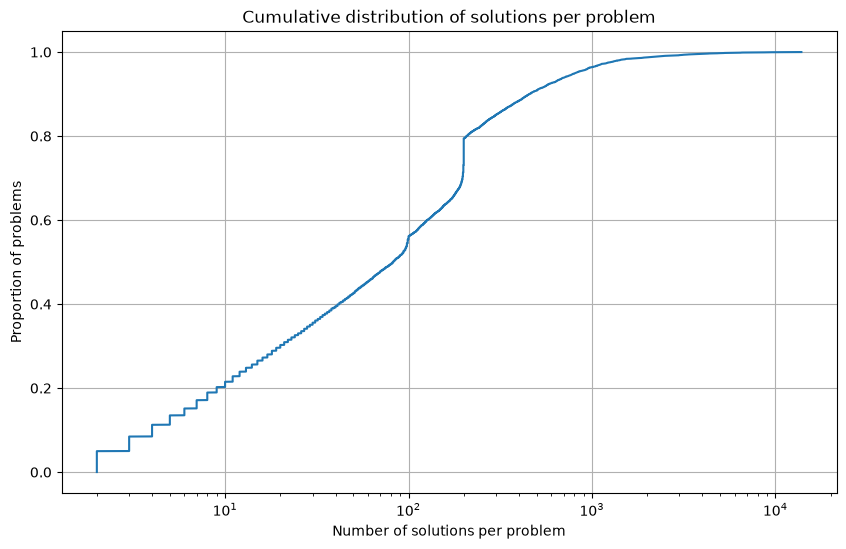

In [24]:
import numpy as np
import matplotlib.pyplot as plt

counts = np.sort(counts.to_numpy())

y = np.arange(1, len(counts) + 1) / len(counts)

plt.figure(figsize=(10, 6))
plt.plot(counts, y)

plt.xscale("log")

plt.xlabel("Number of solutions per problem")
plt.ylabel("Proportion of problems")
plt.title("Cumulative distribution of solutions per problem")

plt.grid(True)
plt.show()

Based on the distribution of the number of solutions per problem, we observe that the median is 82, while the mean is approximately 214. The large difference between the median and mean suggests that the distribution is strongly right-skewed, indicating the presence of problems with an unusually large number of solutions.

The maximum number of solutions for a single problem is approximately 13,856. Keeping all of these solutions could cause some problems to be significantly overrepresented in the training dataset, potentially giving them a disproportionate influence during training.

Conclusion: To maintain a more balanced representation of problems, we impose a maximum threshold on the number of solutions retained per problem. 

Based on the distributions shown in the two visualizations above, we select 500 solutions per problem as the maximum threshold.

In [30]:
filtered_df = df.join(
        df.group_by("problem")
        .agg(
            pl.len().alias("counts")
        ).filter(
            pl.col("counts") <=450
        ).select("problem"),
        on="problem",
        how="semi"
    ).collect()

In [31]:
filtered_df.shape

(609617, 2)

C:\Users\amine\AppData\Local\Temp\ipykernel_28752\3964560088.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(counts, vert=False)


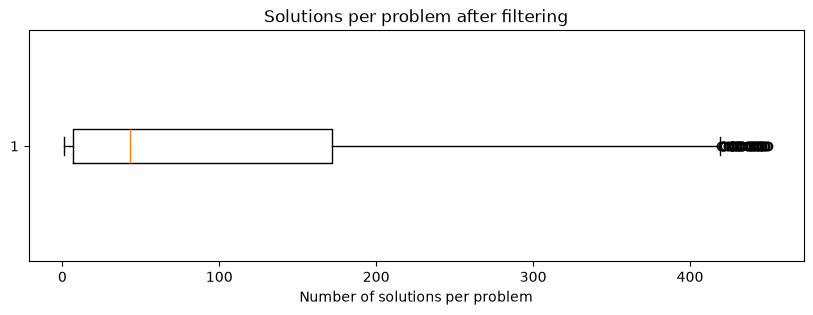

In [32]:
counts = (
    filtered_df
    .group_by("problem")
    .agg(pl.len().alias("counts"))
    ["counts"]
    .to_numpy()
)

plt.figure(figsize=(10, 3))

plt.boxplot(counts, vert=False)

plt.xlabel("Number of solutions per problem")
plt.title("Solutions per problem after filtering")

plt.show()

In [33]:
filtered_df.null_count()

problem,solution
u32,u32
0,0


In [35]:
problem_lengths  =  filtered_df.select(
    pl.col("problem")
    .str.len_chars()
    .alias("length")
    )

In [38]:
problem_lengths["length"].describe()

statistic,value
str,f64
"""count""",609617.0
"""null_count""",0.0
"""mean""",1459.879672
"""std""",695.233903
"""min""",29.0
"""25%""",921.0
"""50%""",1354.0
"""75%""",1873.0
"""max""",12976.0


In [43]:
solution_lengths= filtered_df.select(
        pl.col("solution")
        .str.len_chars()
        .alias("length")
    )

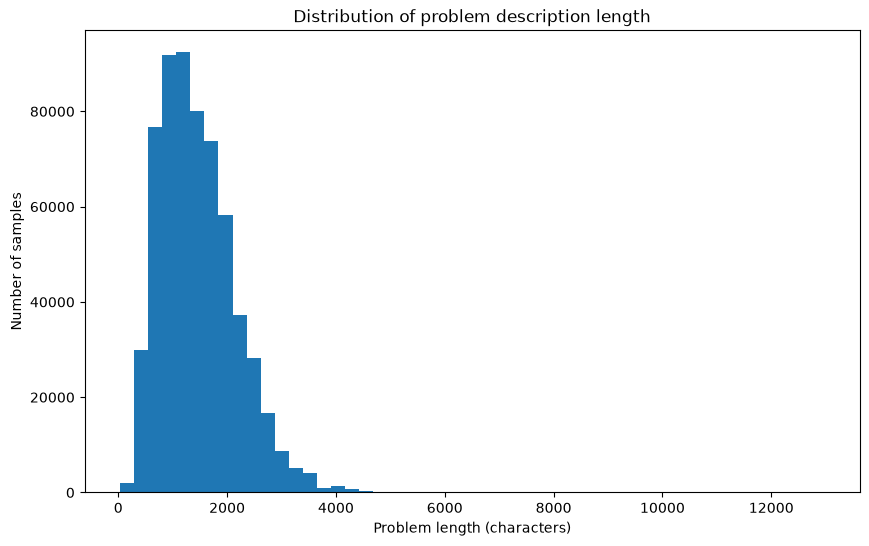

In [41]:
plt.figure(figsize=(10, 6))

plt.hist(
    problem_lengths["length"].to_numpy(),
    bins=50
)

plt.xlabel("Problem length (characters)")
plt.ylabel("Number of samples")
plt.title("Distribution of problem description length")

plt.show()

In [47]:
solution_lengths["length"].describe()

statistic,value
str,f64
"""count""",609617.0
"""null_count""",0.0
"""mean""",593.816319
"""std""",1658.612568
"""min""",10.0
"""25%""",171.0
"""50%""",329.0
"""75%""",616.0
"""max""",464308.0


Observation: The solution-length distribution is strongly right-skewed. The median solution length is 329 characters, while the mean is approximately 594 characters. The substantial difference between the median and mean, together with the maximum length of 464,308 characters, indicates the presence of extremely long solutions that significantly influence the distribution.

The 25th percentile is 171 characters and the 75th percentile is 616 characters, meaning that 50% of the solutions have lengths between 171 and 616 characters. This shows that most solutions are relatively short, while a small number of exceptionally long solutions form a long right tail.

Conclusion: The presence of extremely long solutions should be investigated before training. For the current dataset analysis, character length is sufficient to identify unusually long solutions and understand the overall distribution. A token-level analysis can be performed later once the model and tokenizer are finalized.

In [48]:
filtered_df = filtered_df.filter(
    pl.col("solution")
    .str.len_chars() <= 616 
)

In [49]:
filtered_df.shape

(457543, 2)

In [ ]:
# shuffle before writing to disk 
filtered_df = filtered_df.sample(fraction=1.0,shuffle=True,seed=42)

In [50]:
# save the final dataset 
filtered_df.write_parquet(training_path / "cleaned.parquet")

In [1]:
import polars as pl 
val_df = pl.read_parquet("../data/processed/valid")

In [2]:
val_df

problem,solution
str,str
"""British mathematician John Lit…","""from math import gcd class Seg…"
"""British mathematician John Lit…","""from math import gcd for _ in…"
"""British mathematician John Lit…","""def main(): mod=…"
"""Consider a sequence of integer…","""# ---------------------------i…"
"""A tree is an undirected connec…","""# ------------------- fast io …"
…,…
"""You are given four integer val…","""for _ in range(int(input())): …"
"""You are given four integer val…","""for _ in range(int(input())): …"
"""You are given four integer val…","""T=int(input()) for i in range(…"


In [4]:
val_df = val_df.sample(fraction=1.0,shuffle=True,seed=42)
val_df.write_parquet("../data/processed/valid/part-0.parquet")